In [ ]:
import os
import pypsa
import pycountry
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

from unit_helpers import (
    tj_to_twh,
    bcm_to_twh,
)

from data_preparing import (
    plot_total_gas_supply,
    add_shared_row_title,
    basic_axis_formatting,
    plot_stacked_bars,
    get_model_pipeline_imports,
    plot_pipeline_imports,
    plot_eu_gas_stock,
    plot_residential_commercial_demand,
    plot_industry_demand,
    industry_demands,
    rescom_demands,
    plot_country_consumption,
)

In [2]:
path = Path.cwd().parent / 'resources'
regions = gpd.read_file(path / 'regions_onshore_base_s_50.geojson')
path = Path.cwd().parent / 'results' / 'networks'
n = pypsa.Network(path / 'base_s_50_24H_24H-T-H-B-I-A-dist1_2025.nc')

/home/lukas/micromamba/envs/pypsa-eur/lib/python3.12/site-packages/pyogrio/__init__.py:7: DeprecationWarning: The 'shapely.geos' module is deprecated, and will be removed in a future version. All attributes of 'shapely.geos' are available directly from the top-level 'shapely' namespace (since shapely 2.0.0).
  import shapely.geos  # noqa: F401
INFO:pypsa.io:Imported network base_s_50_24H_24H-T-H-B-I-A-dist1_2025.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [8]:
from gas_validation_data import (
    df_2024_residential,
    df_2024_industrial,
    df_2024_production,
    df_pipeline_imports,
    df_total_supply,
    df_storage_2024,
)

df_2024_residential = bcm_to_twh(df_2024_residential)
df_2024_industrial = bcm_to_twh(df_2024_industrial)
df_2024_production = bcm_to_twh(df_2024_production)
df_pipeline_imports = bcm_to_twh(df_pipeline_imports)
df_total_supply = bcm_to_twh(df_total_supply)
df_storage_2024 = bcm_to_twh(df_storage_2024)

ccon = pd.read_csv(
    'nrg_cb_gas$defaultview_linear_2_0.csv'
)
ccon = (
    ccon.loc[ccon['TIME_PERIOD'] == 2024]
    .set_index('Geopolitical entity (reporting)')
    ['OBS_VALUE']
    .rename('gas_demand')
    .apply(tj_to_twh)
)

def country_name_to_iso2(name):
    name = name.strip()
    try:
        return pycountry.countries.lookup(name).alpha_2
    except LookupError:
        return None

ccon = ccon.copy()
ccon.index = ccon.index.map(country_name_to_iso2)
ccon = ccon[~ccon.index.isnull()]
ccon = ccon.sort_values(ascending=False)

In [9]:
gens = n.generators.index[n.generators.carrier == 'gas']

In [10]:
n.statistics

yet to implement other pipeline representation in model!


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

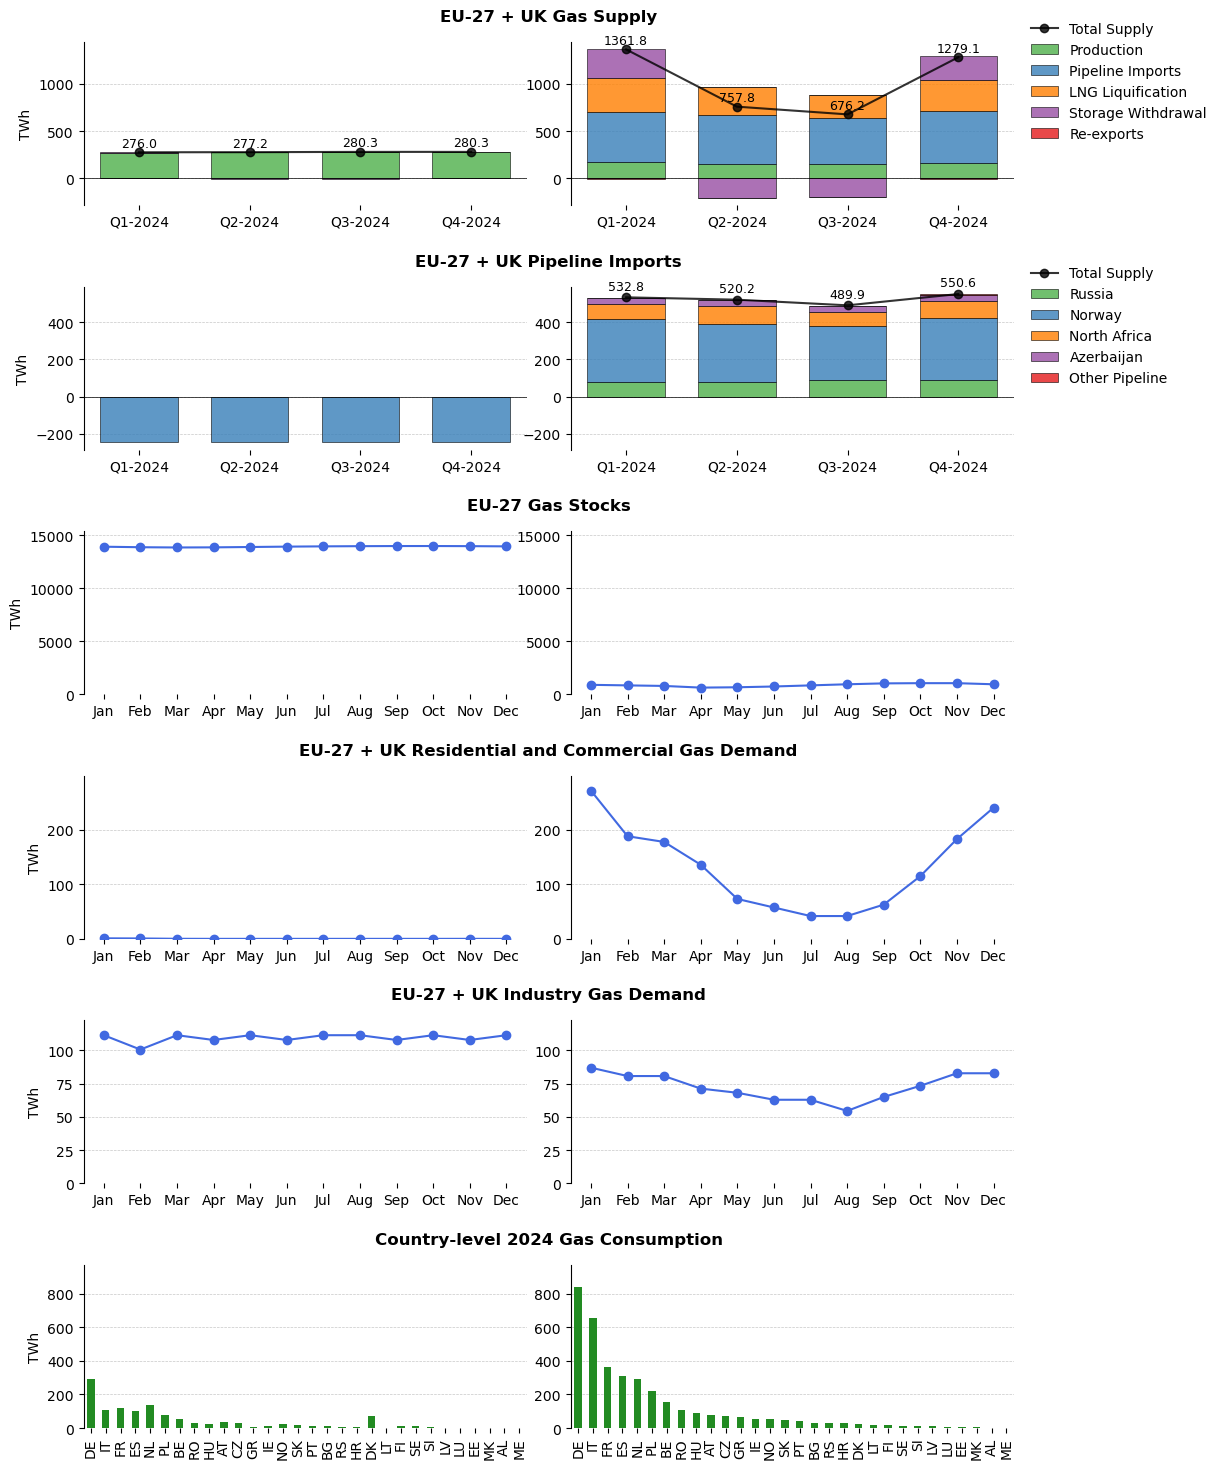

In [ ]:

fig_height = 3 * 6  # 3 inches per row
fig_width = 12      # 2*2*3 = 12 inches for 2:1 aspect per ax, 2 axes per row
fig, axes = plt.subplots(
    nrows=6,
    ncols=2,
    figsize=(fig_width, fig_height),
    gridspec_kw={'wspace':0.1, 'hspace':0.5}
    )

row_fns = [
    plot_total_gas_supply,
    plot_pipeline_imports,
    plot_eu_gas_stock,
    plot_residential_commercial_demand,
    plot_industry_demand,
    plot_country_consumption,
]

right_data_list = [
    df_total_supply,
    df_pipeline_imports,
    df_storage_2024,
    df_2024_residential,
    df_2024_industrial,
    ccon,
]

for i in range(6):
    model_ax = axes[i, 0]
    true_ax = axes[i, 1]
    row_fns[i](model_ax, true_ax, n, right_data_list[i], fig, i)

    model_ax.set_xlabel("")
    model_ax.set_ylabel("")
    true_ax.set_xlabel("")
    true_ax.set_ylabel("")

    fig.canvas.draw()  # Needed to ensure positions are up to date
    bbox1 = model_ax.get_position()
    bbox2 = true_ax.get_position()

    x0 = bbox1.x1 - 0.02 * (bbox2.x0 - bbox1.x1)  # slight overlap
    width = bbox2.x0 - bbox1.x1 + 0.04 * (bbox2.x0 - bbox1.x1)
    y0 = bbox1.y0
    height = bbox1.height

    bbox_top = model_ax.get_position()
    bbox_bottom = model_ax.get_position()
    y0 = bbox_bottom.y0
    height = (bbox_top.y1 - bbox_bottom.y0) / 5

    '''
    rect = patches.FancyBboxPatch(
        (x0, y0), width, height,
        boxstyle="round,pad=0.02",
        linewidth=1, edgecolor='gray', facecolor='white', alpha=0.95,
        transform=fig.transFigure, zorder=10
    )

    fig.patches.append(rect)

    fig.text(
        x0 + width/2, y0 + height/2,
        f"Legend/Explanation\nPlaceholder\n(Row {i+1})",
        ha='center', va='center', fontsize=10, color='black', zorder=11
    )
    '''

for ax in axes[:,0]:
    ax.set_ylabel('TWh')

plt.savefig('validation_starting_point.pdf', bbox_inches='tight')
plt.show()